In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit



0.6777 74.71913613009617 74.71913613009617


In [2]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 40, (40-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [3]:
# bin sim data in bins of R
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos  = []
vphyslos = []
rlos = []
R = []
M = []

with h5.File(vel_path, 'r') as hdf:
    for k, m in enumerate(Mvirs):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos.append(vpec[mask])
            vphyslos.append(vphys[mask])
            rlos.append(rel_rlos[mask])
            R.append(rel_R[mask])
            M.append(Mvir[mask])

In [4]:
# and now bins of R, rlos

vpeclos1 = []
vphyslos1 = []
R1 = []
rlos1 = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]
        
        for i, R in enumerate(r_cens):
            Rmask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
            rel_R_masked = rel_R[Rmask]
            rel_rlos_masked = rel_rlos[Rmask]
            vpec_masked = vpec[Rmask]
            vphys_masked = vphys[Rmask]

            
            for j, rlos in enumerate(rlos_cens):
                rmask = (rel_rlos_masked >= rlos_edges[j]) & (rel_rlos_masked <= rlos_edges[j+1])
                
                vpeclos1.append(vpec_masked[rmask])
                rlos1.append(rel_rlos_masked[rmask])
                R1.append(rel_R_masked[rmask])
                vphyslos1.append(vphys_masked[rmask])

In [4]:
v_r, rbin, vr_sbids = bin_velocities_abs(path='/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', vel='v_r', binning='r', Rbins=rlos_edges, massbins=mbins, return_sbid=True) 

Number of bins: 240


In [5]:
# plot <v_r|r>
mean_vr_r = np.zeros((len(Mvirs), len(rlos_cens)))
peak_vr_r = np.zeros((len(Mvirs), len(rlos_cens)))

for k in range(len(Mvirs)):
    for i in range(len(rlos_cens)):
        index = i + k*(len(rlos_cens))

        hist, edges = np.histogram(v_r[index], bins='auto', range=[-4000, 4000])
        cent = 0.5*(edges[1:] + edges[:-1])

        peak = cent[np.argmax(hist)]
        mean = np.mean(v_r[index])

        if np.isnan(mean):
            print(k, i, mean, v_r[index])
            break

        mean_vr_r[k, i] = mean
        peak_vr_r[k, i] = peak

Text(0.5, 0, '$r \\ [h^{-1}$ Mpc]')

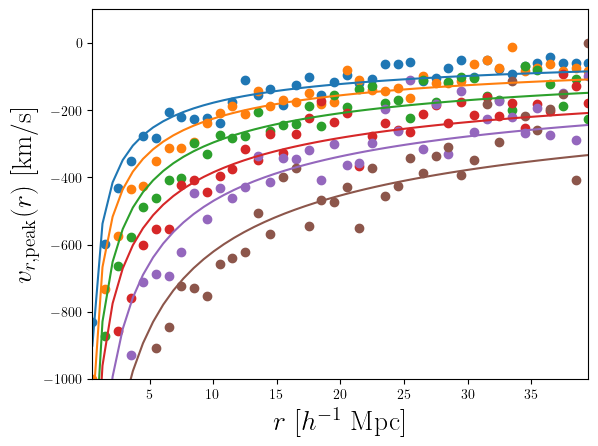

In [6]:
from scipy.interpolate import interp1d 

vr_pars = np.zeros((len(Mvirs), 2))
vr_errs = np.zeros((len(Mvirs), 2))


for k in range(len(Mvirs)):
    plt.scatter(rlos_cens, peak_vr_r[k], color=f'C{k}')

    p, c = curve_fit(plaw, rlos_cens/20, peak_vr_r[k])
    vr_pars[k] = p
    vr_errs[k] = np.sqrt(np.diag(c))

    rloss = np.linspace(rlos_cens.min(), rlos_cens.max())

    plt.plot(rloss, plaw(rloss/20, p[0], p[1]))

plt.ylim((-1000, 100))
plt.margins(x=0)
plt.ylabel(r"$v_{r, \rm peak}(r)$ [km/s]", fontsize=20)
plt.xlabel(r"$r \ [h^{-1}$ Mpc]", fontsize=20)

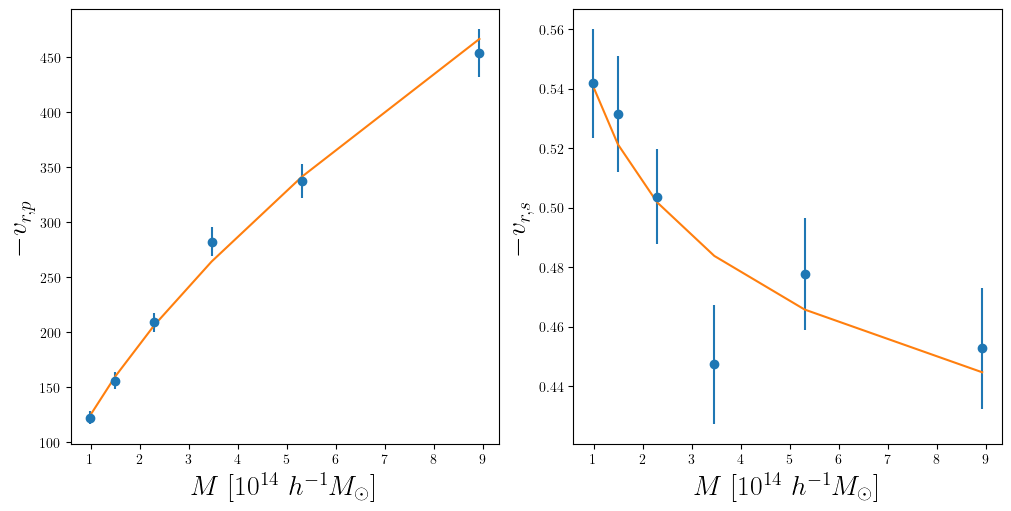

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

vrm_pars = np.zeros((vr_pars.shape[-1], 2))

labels = [r"$v_{r, p}$", r"$v_{r, s}$"]

for i in range(vr_pars.shape[-1]):

    p, c = curve_fit(plaw, Mvirs/1e14, -vr_pars[:, i], sigma=vr_errs[:, i])
    vrm_pars[i] = p 

    ax[i].errorbar(Mvirs/1e14, -vr_pars[:, i], vr_errs[:, i], fmt='o')
    ax[i].plot(Mvirs/1e14, plaw(Mvirs/1e14, p[0], p[1]))
    ax[i].set_xlabel(r"$M \ [10^{14} \ h^{-1} M_\odot]$",  fontsize=20)
    ax[i].set_ylabel(r"$-$"+labels[i], fontsize=20)

In [8]:
# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

print(N_halos)

[15071.  8200.  4095.  1691.   676.   246.]


In [9]:
r_fine_edges = np.linspace(5, 50, 100)
r_fine_cens = 0.5*(r_fine_edges[1:]+r_fine_edges[:-1])

rho_RM = np.zeros((6, len(r_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_fine_cens)):
            
            r_mask = (rs >= r_fine_edges[j])&(rs <= r_fine_edges[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_fine_edges[j+1]**3 - r_fine_edges[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM[k, j] = rho

In [10]:
# try interpolating density profile

from scipy.interpolate import RegularGridInterpolator

rho_interp = RegularGridInterpolator((Mvirs, r_fine_cens), rho_RM, method='cubic', bounds_error=False, fill_value=None)


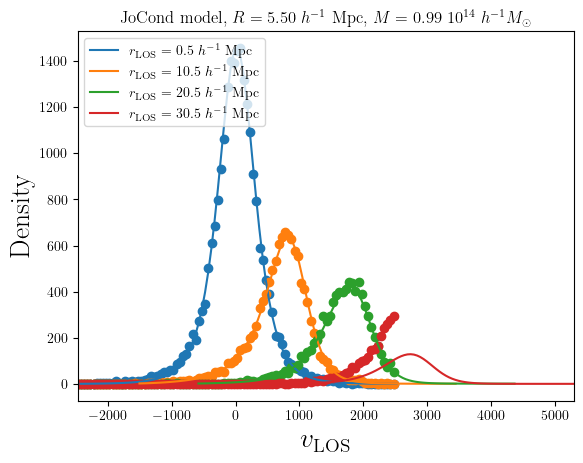

In [9]:
# Jocond model
j, k = 0, 0 # R and M bins
indices = [0, 10, 20, 30]
rloss = np.array([rlos_cens[i] for i in indices])

vedges = np.linspace(-2500, 2500, 100+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

# th, _, _ = plt.hist(vphyslos[j + k*len(r_cens)], bins=50, density=True)
models = np.zeros((len(indices), len(vcens)))

for i in indices:

    index = i + j*len(r_cens) + k*len(r_cens)*len(Mvirs)

    hist, bins = np.histogram(vphyslos1[index], bins=vedges, density=False)
    cens = 0.5*(bins[1:] + bins[:-1])

    plt.scatter(cens, hist, c=f'C{i//10}')

    model = P_vlos_R_rlos(cens, r_cens[j], rlos_cens[i], Mvirs[k] )
    models[i//10] = model

    plt.plot(cens+a*H*rlos_cens[i]/h, np.sum(hist)*np.diff(cens)[0]*model, c=f'C{i//10}', label=rf"$r_{{\rm LOS}} = {rlos_cens[i]}\ h^{{-1}}$ Mpc")
    #plt.plot(cens, model, c=f'C{i//10}', label=rf"$r_{{\rm LOS}} = {rlos_cens[i]}\ h^{{-1}}$ Mpc")

# dens = 0.014*(cf_inf(np.sqrt(r_cens[j]**2 + rloss**2), Mvirs[k], cf_pars) + 1)
# integ = np.mean(models*dens[:, None], axis=0)
# plt.plot(cens, integ/np.sum(integ*np.diff(cens)[0]), c='k', label='Mean of curves')

plt.legend(loc='upper left')
plt.title(rf"JoCond model, $R={r_cens[j]:.2f}\ h^{{-1}}$ Mpc, $M={(Mvirs[k]/1e14):.2f}\ 10^{{14}} \ h^{{-1}} M_\odot$")
plt.xlabel(r"$v_{\rm LOS}$", fontsize=20)
plt.ylabel(r"Density", fontsize=20)
plt.margins(x=0)
#plt.ylim((0, 0.0015))

In [14]:
vedges = np.linspace(-2500, 2500, 100+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

In [15]:
j, k = 0, 0

vphys = vcens 
R = r_cens[j] 
M = Mvirs[k] 
pars=jocond.myconfig.joint_MAP

rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

# rlos integration range
rlos_max = 40 
rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

rlos_vals = rlos_cens

vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

vr_e = np.linspace(-4000, 4000, 100+1)
vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

Pvlos_grid = np.array(
    [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
)

Pvlos_interp_list = []

for j in range(len(rlos_vals)):
    interp_func = interp1d(
        vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
    )
    interpolated = interp_func(vpec[:, j])

    Pvlos_interp_list.append(interpolated)

Pvlos_interp = np.array(Pvlos_interp_list)
Pvlos_interp = Pvlos_interp.T

r3d = np.sqrt(R**2 + rlos_vals**2)
weight = np.array([rho_interp((M, ri)) for ri in r3d]) #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

integrand = Pvlos_interp * weight[None, :]
P_out = simpson(integrand, x=rlos_vals, axis=1)

sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
P_out /= sigma_R

In [72]:
# and now bins of R, rlos

rlos_max = 40 
rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1)) # sync with abovee, depending on what you are trying to do
rlos_cens = 0.5*(rlos_edges[1:] + rlos_edges[:-1])

vpeclos1 = []
vphyslos1 = []
R1 = []
rlos1 = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]
        
        for i, R in enumerate(r_cens):
            Rmask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
            rel_R_masked = rel_R[Rmask]
            rel_rlos_masked = rel_rlos[Rmask]
            vpec_masked = vpec[Rmask]
            vphys_masked = vphys[Rmask]

            
            for j, rlos in enumerate(rlos_cens):
                rmask = (rel_rlos_masked >= rlos_edges[j]) & (rel_rlos_masked <= rlos_edges[j+1])
                
                vpeclos1.append(vpec_masked[rmask])
                rlos1.append(rel_rlos_masked[rmask])
                R1.append(rel_R_masked[rmask])
                vphyslos1.append(vphys_masked[rmask])

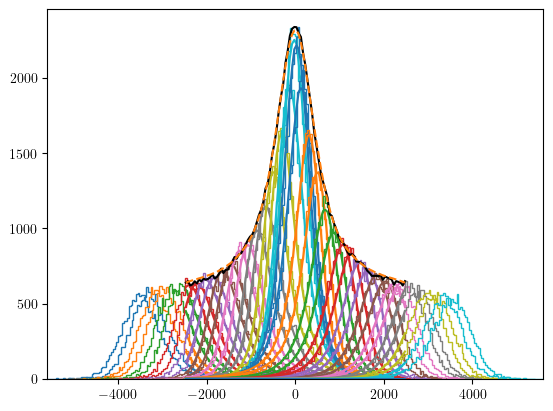

In [88]:
j, k = 0, 0

norm = 0
edges = np.zeros(100)

hists = np.zeros((len(rlos_cens), 100))



for i in range(0, len(rlos_vals)):
    index = i+j*len(rlos_cens) + k*len(r_cens)*len(rlos_cens)

    peak = a*H*rlos_cens[i]/h
    ve = np.linspace(peak - 2000, peak + 2000, 100+1)

    th, _, _ = plt.hist(vphyslos1[index], bins = ve, histtype='step', density=False, color=f"C{i//2}")
    plt.plot(vphys, np.sum(th)*np.diff(ve)[0]*Pvlos_interp.T[i], c=f"C{i//2}") 

    # if i == len(rlos_cens)//2:
    norm += np.sum(th)
    #edges = ve

    hists[i] = th

vpth, _ = np.histogram(vphyslos[0], bins=vedges, density=False)
plt.plot(vphys, vpth/6.5, c='k')

plt.plot(vphys, np.sum(vpth)*np.diff(vedges)[0]*P_out/simpson(P_out, x=vphys)/6.5, ls='--', color='C1')


#test_integrand = hists * weight[None, :]
test_P_out = simpson(hists, x=rlos_vals, axis=0)

plt.plot(vphys, test_P_out/simpson(test_P_out, x=vphys))

plt.margins(x=0)

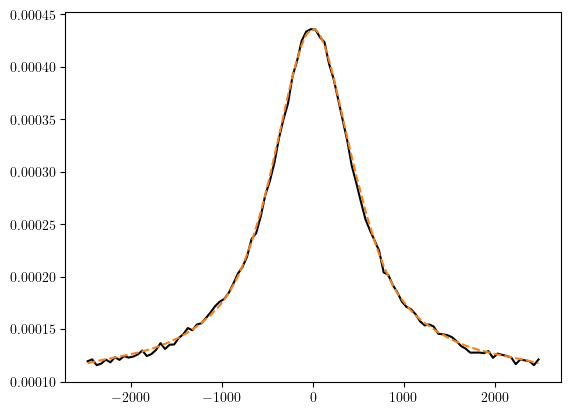

In [25]:
vpth, _ = np.histogram(vphyslos[0], bins=vedges, density=True)
plt.plot(vcens, vpth, c='k')

plt.plot(vcens, P_out/simpson(P_out, x=vcens), ls='--', color='C1')


In [21]:
def P_vphys_R_dens(vphys, R, M, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    vr_e = np.linspace(-4000, 4000, 100)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    Pvlos_grid = np.array(
        [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(
            vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = np.array([rho_interp((M, ri)) for ri in r3d]) #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / simpson(P_out, x=vphys)


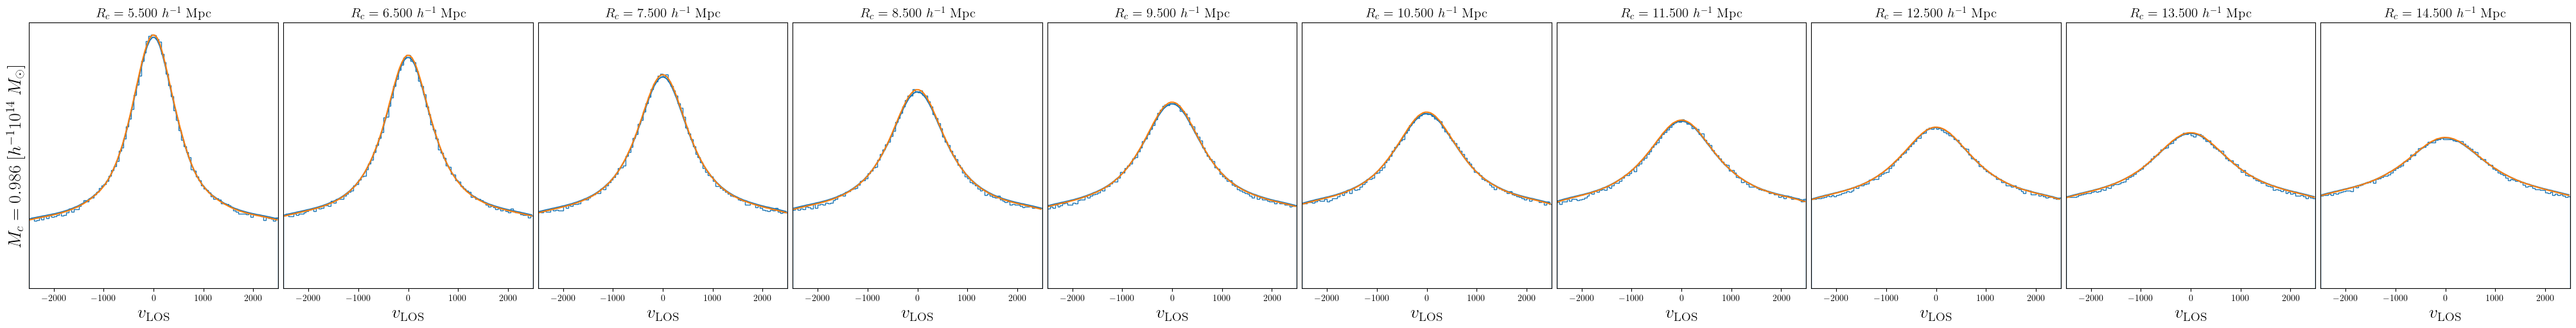

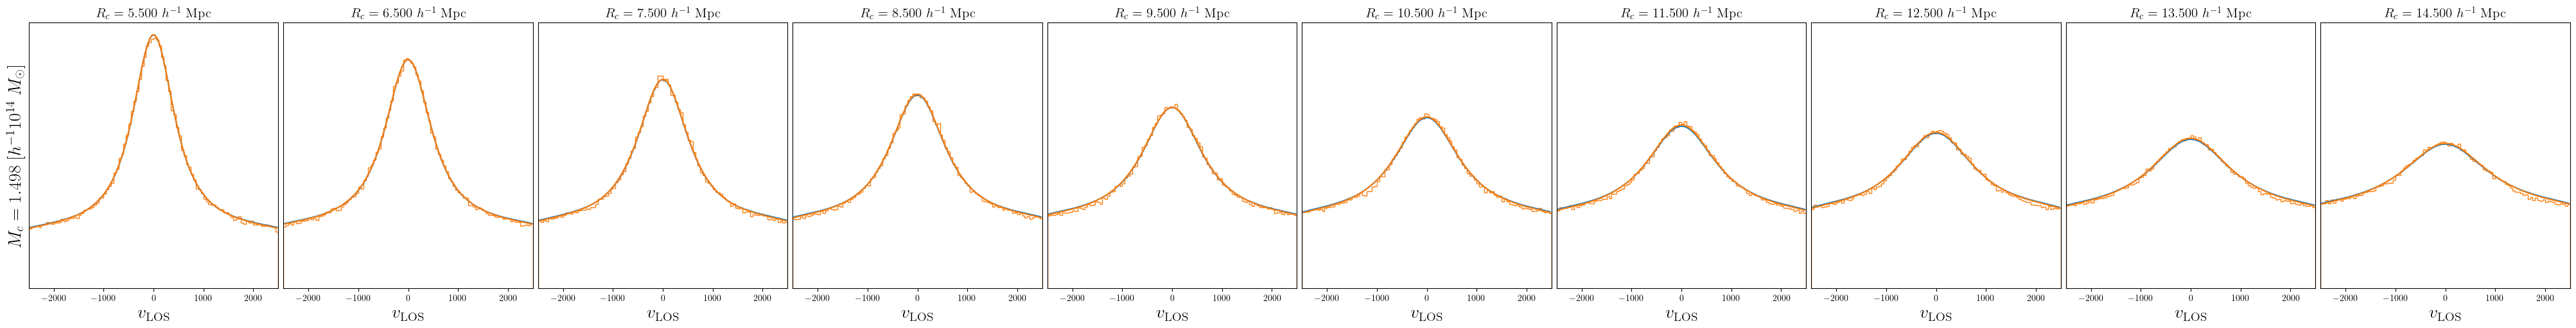

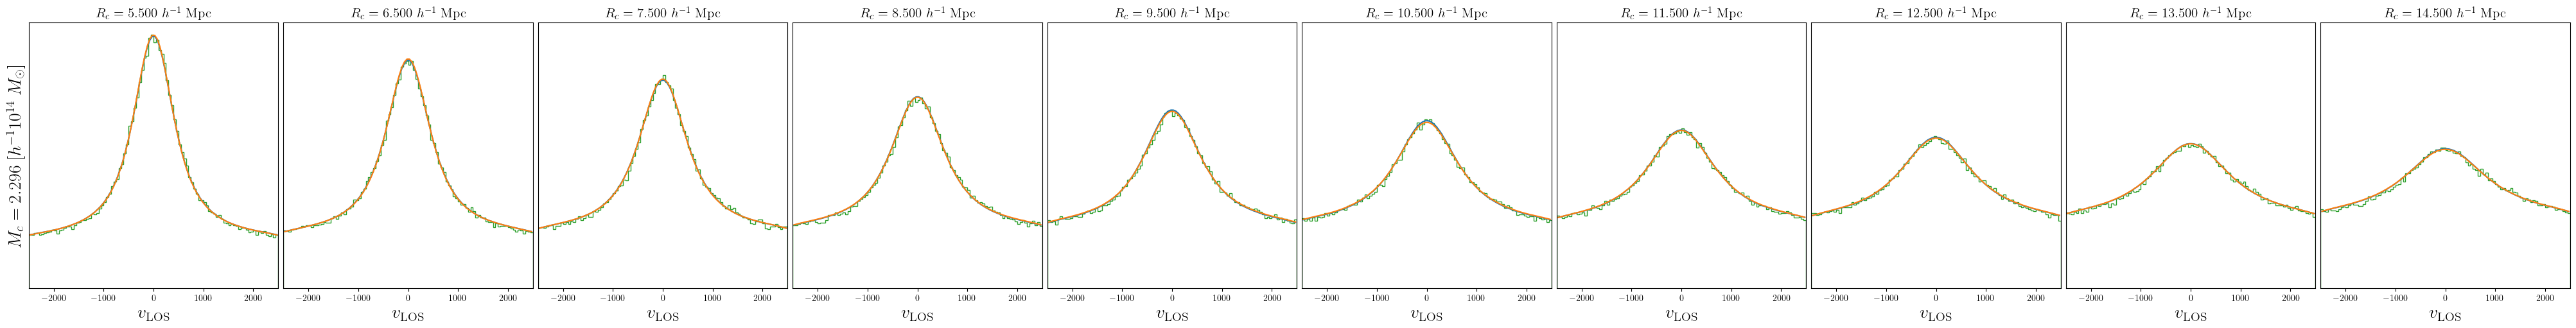

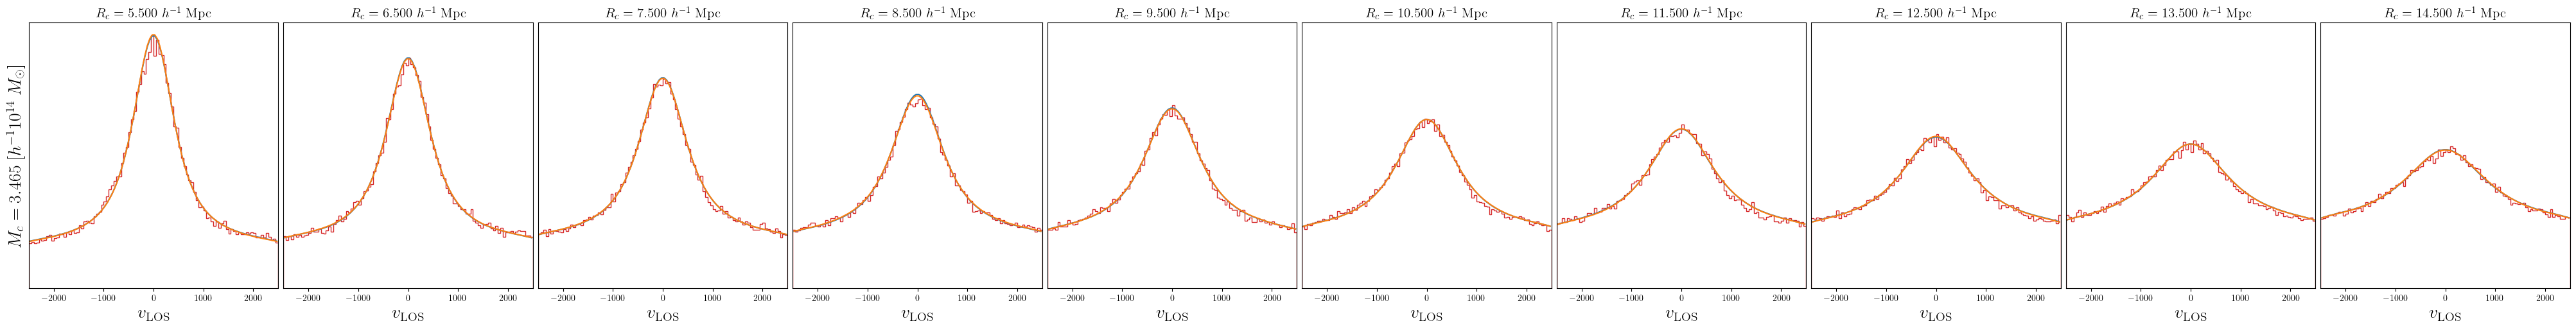

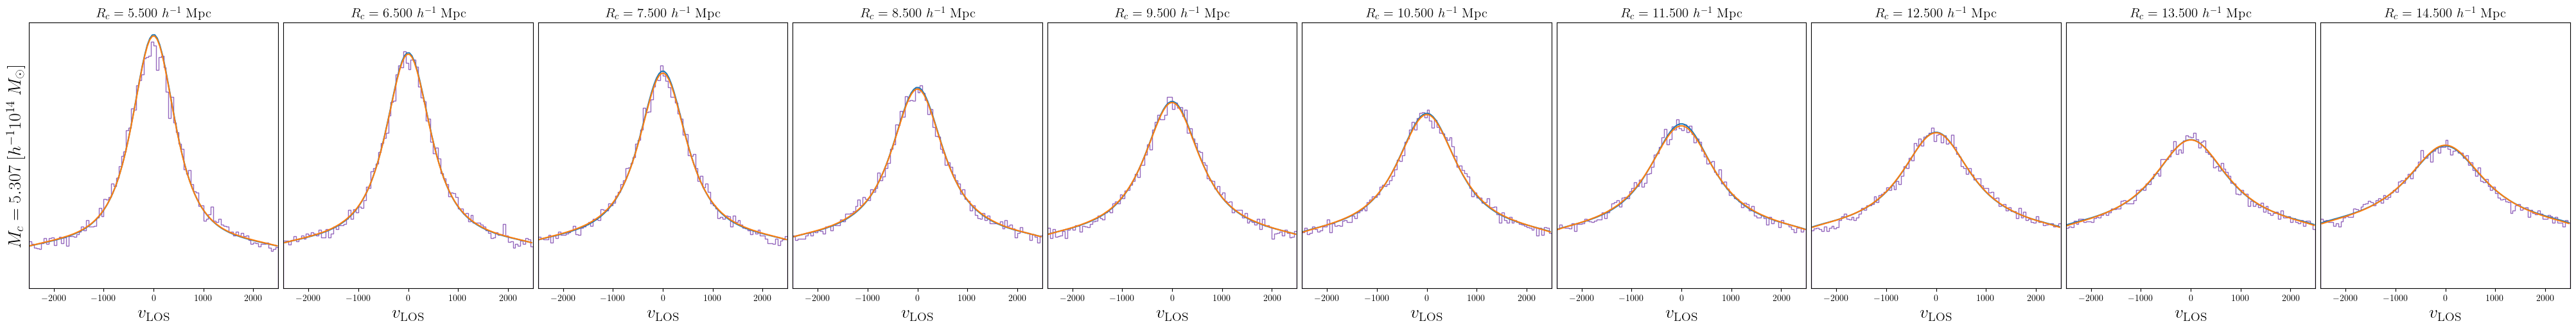

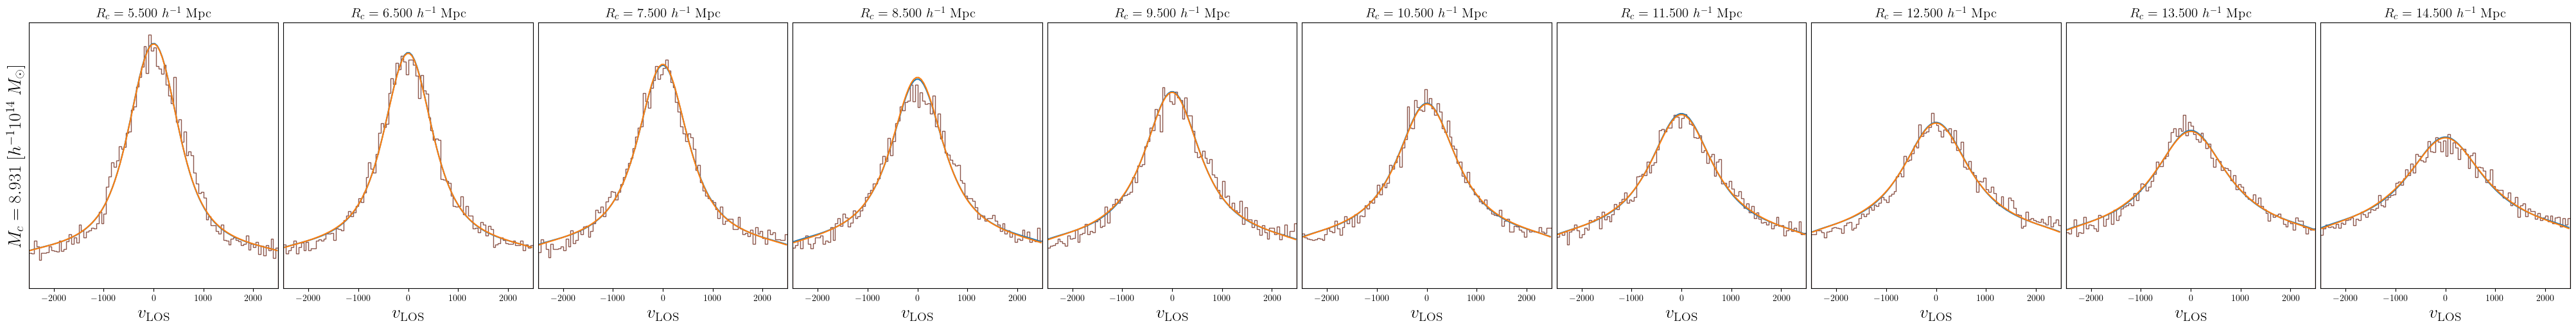

In [22]:

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos[index], bins=vedges, density=True, histtype='step', color=f'C{k}')

        ax[i].plot(vcens, P_vphys_R(vcens, r_cens[i], Mvirs[k]), c=f'C0')
        ax[i].plot(vcens, P_vphys_R_dens(vcens, r_cens[i], Mvirs[k]), c=f'C1')
        
        ax[i].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[i].set_title(rf"$R_c = {r_cens[i]:.3f} \ h^{{-1}}$ Mpc", fontsize=15)
        ax[i].set_yticks([])
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M_c = {(Mvirs[k]/1e14):.3f} \ [h^{{-1}} 10^{{14}} \ M_\odot]$", fontsize=20)

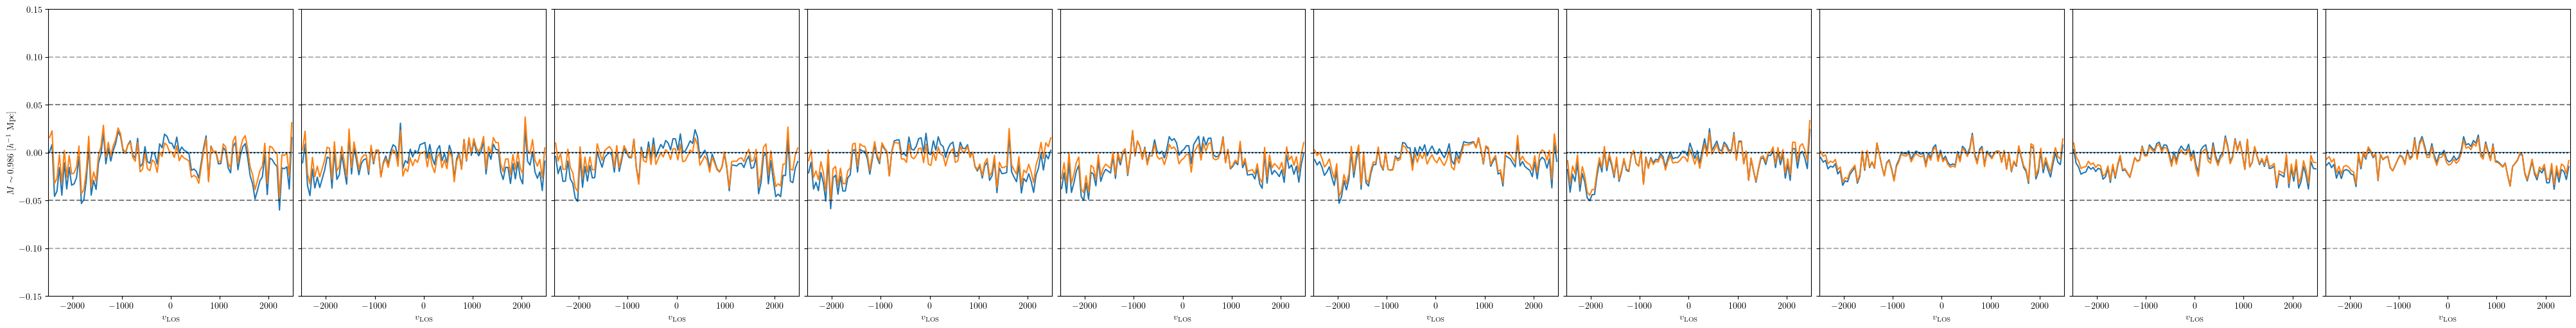

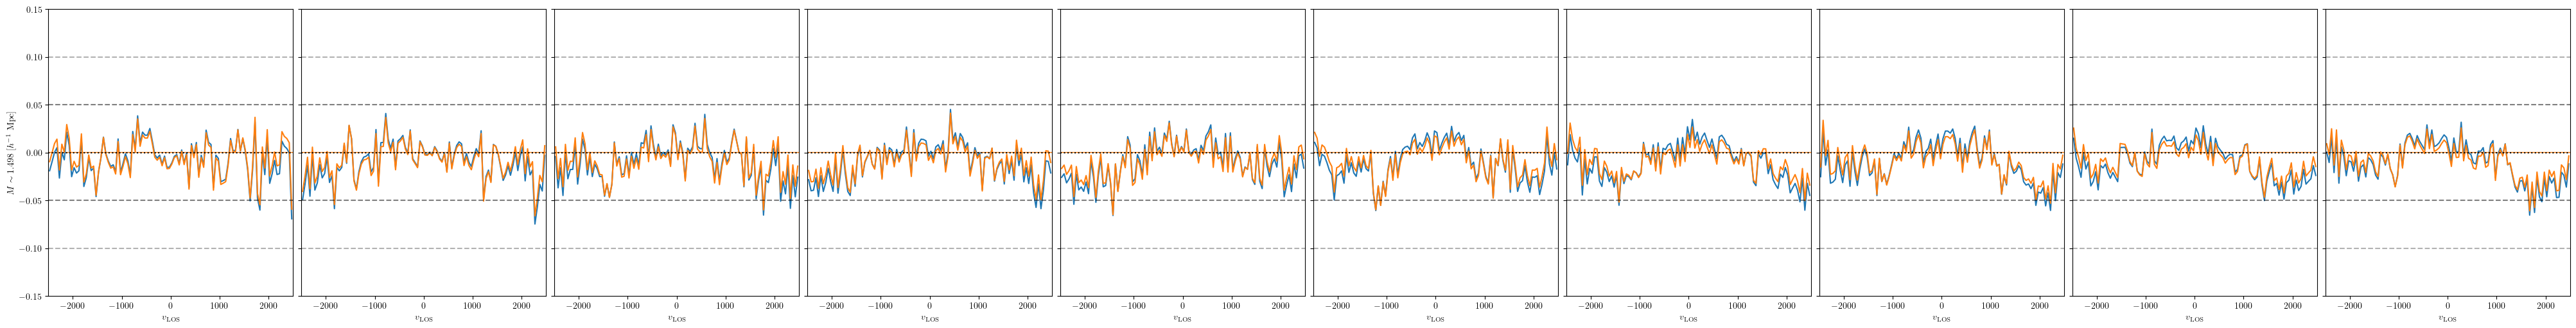

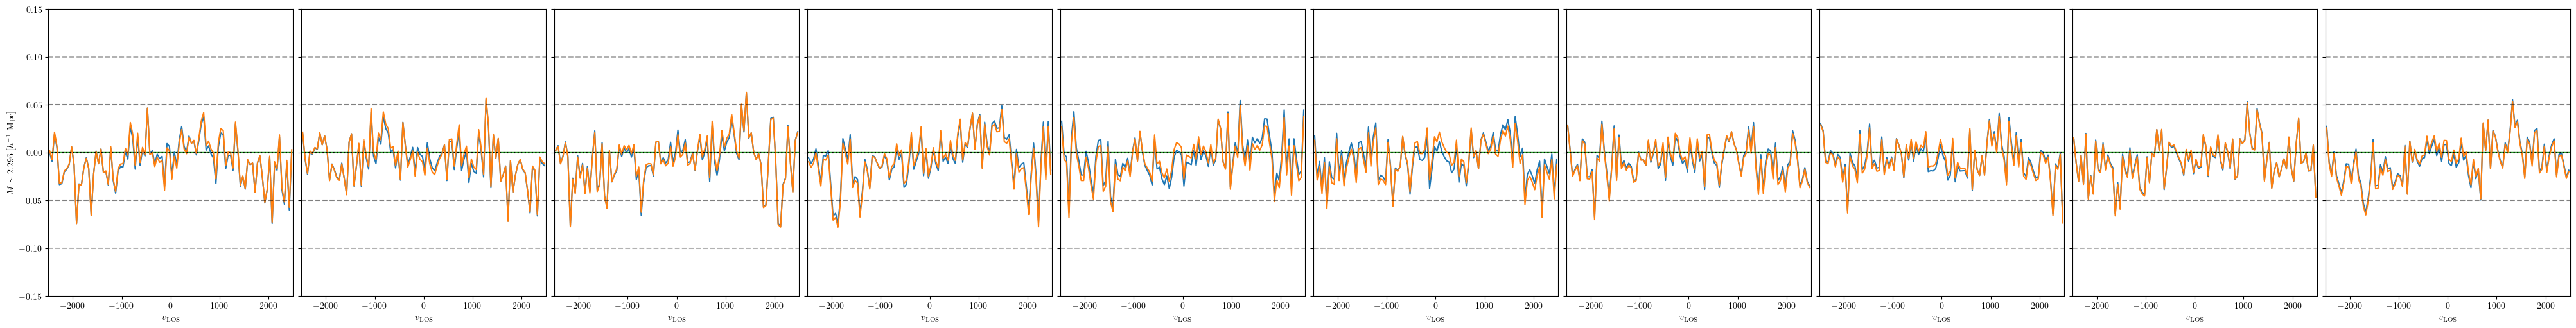

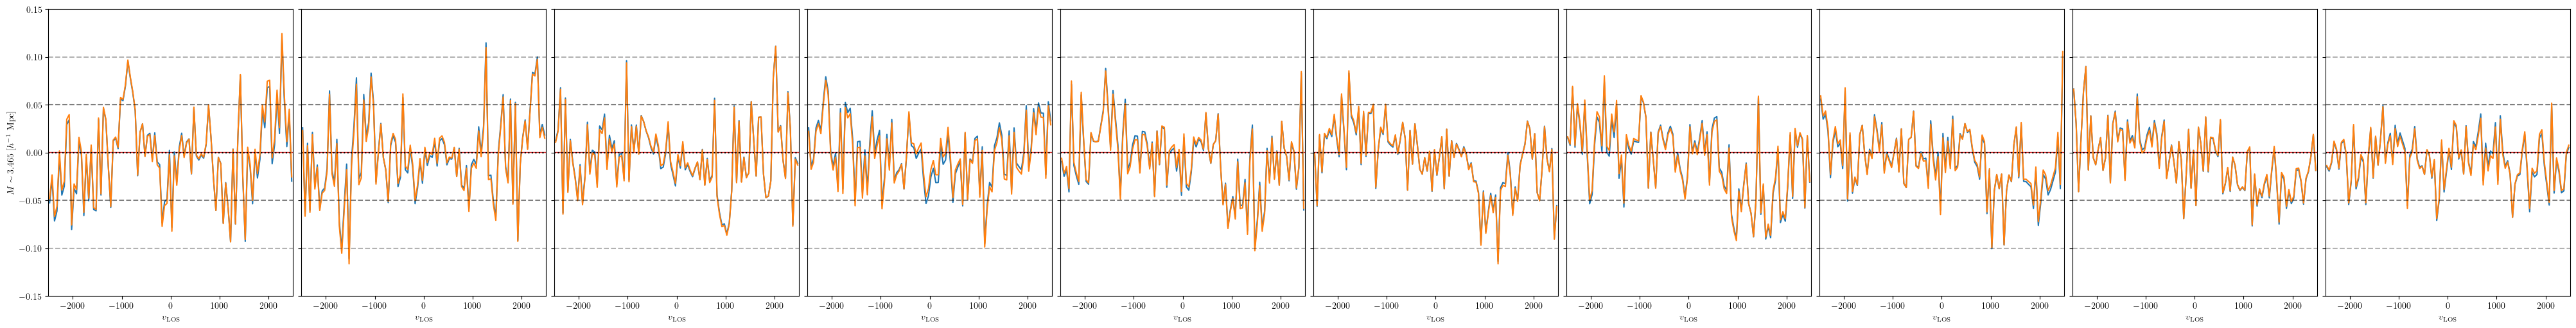

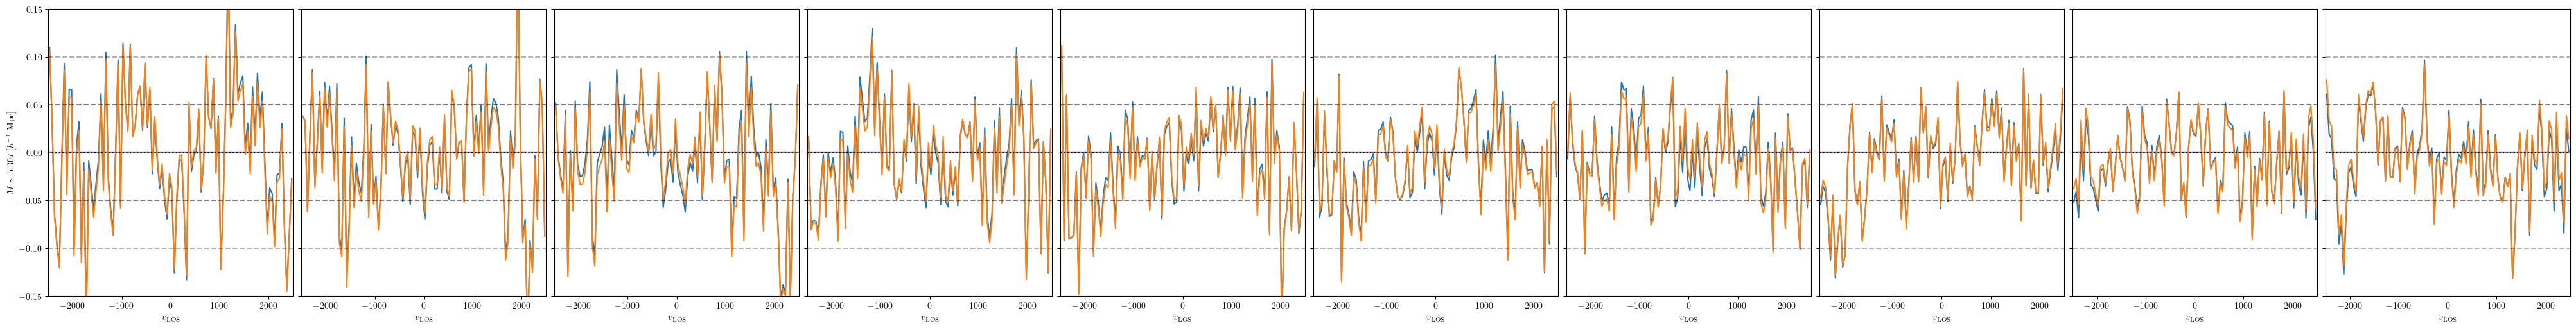

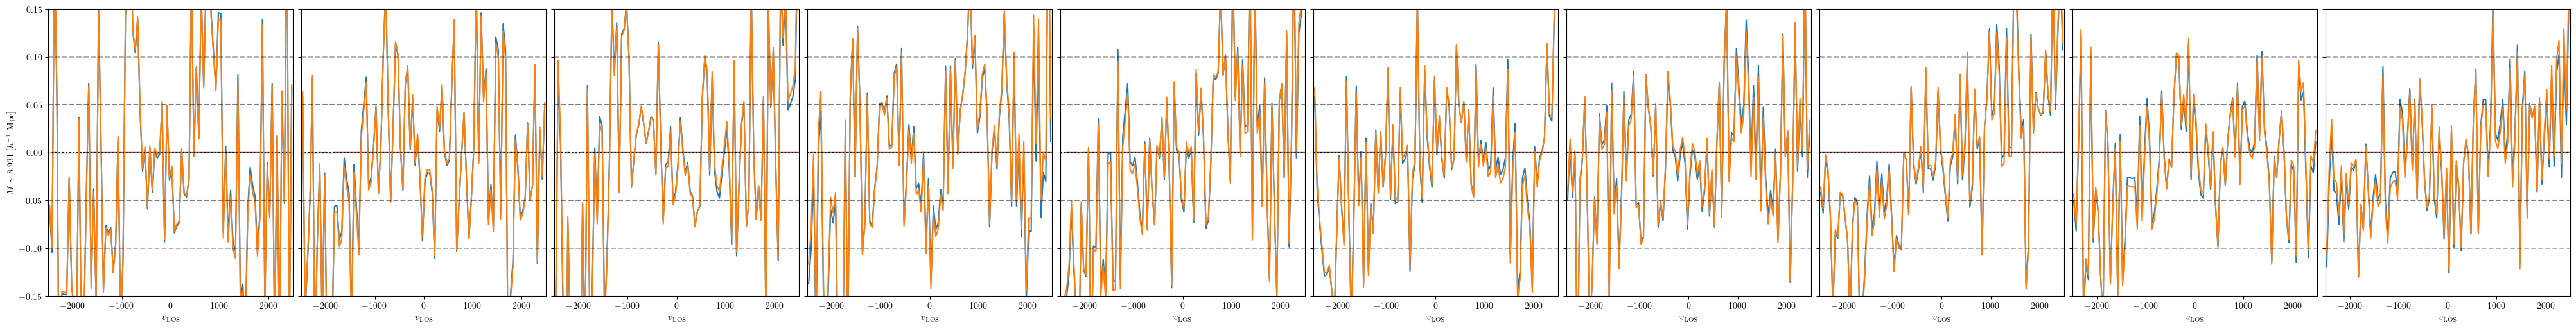

In [23]:
for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos[index], bins=vedges, density=True, histtype='step', color=f'C{k}')
        model = P_vphys_R(vcens, r_cens[i], Mvirs[k])
        model_dens = P_vphys_R_dens(vcens, r_cens[i], Mvirs[k])

        ax[i].plot(vcens, (hist-model)/model, c=f'C0') 
        ax[i].plot(vcens, (hist-model_dens)/model_dens, c=f'C1') 

        ax[i].axhline(0, ls=':', color='k')
        ax[i].axhline(0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(-0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(0.1, ls='--', color='k', alpha=0.3)
        ax[i].axhline(-0.1, ls='--', color='k', alpha=0.3)

        ax[i].set_xlabel(r"$v_{\rm LOS}$")
        #ax[i].set_yticks([])
        ax[i].set_ylim((-0.15, 0.15))
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M\sim {(Mvirs[k]/1e14):.3f} \ [h^{{-1}}$ Mpc]")

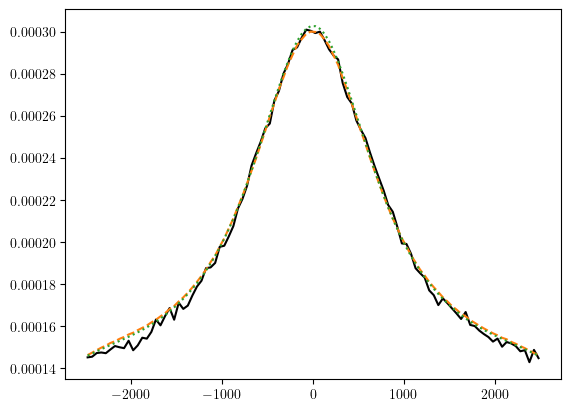

In [30]:
j, k = 5, 0

vpth, _ = np.histogram(vphyslos[j+k*len(r_cens)], bins=vedges, density=True)
plt.plot(vcens, vpth, c='k')

plt.plot(vcens, P_vphys_R(vcens, r_cens[j], Mvirs[k]), ls='--', color='C1')
plt.plot(vcens, P_vphys_R_test(vcens, r_cens[j], Mvirs[k]), ls=':', c='C2')

In [ ]:
    index = i+j*len(rlos_cens) + k*len(r_cens)*len(rlos_cens)

    peak = a*H*rlos_cens[i]/h
    ve = np.linspace(peak - 2000, peak + 2000, 100+1)

    th, _, _ = plt.hist(vphyslos1[index], bins = ve, histtype='step', density=False, color=f"C{i//2}")

In [66]:
rlos_cens = 0.5*(rlos_edges[1:] + rlos_edges[:-1])

In [108]:
def P_vphys_R_hists(vphys, R_ind, M_ind, H=74.719, a=0.83760, h=0.6777):

    R = r_cens[R_ind]
    M = Mvirs[M_ind]
    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1)) # dont change without changing binning above!!
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    # vr_e = np.linspace(-4000, 4000, 100)
    # vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    # Pvlos_grid = np.array(
    #     [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    # )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        index = j+R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)

        peak = a*H*rlos_cens[j]/h
        ve = np.linspace(peak - 2500, peak + 2500, 100+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        th, _ = np.histogram(vphyslos1[index], bins = ve, density=True)

        interp_func = interp1d(
            vc, th, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vphys))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = np.array([rho_interp((M, ri)) for ri in r3d]) #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]

    P_out = simpson(integrand, x=rlos_vals, axis=1)

    #sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    #P_out /= sigma_R

    return P_out / simpson(P_out, x=vphys)

In [138]:


def P_vphys_R_test(vphys, R, M, pars=jocond.myconfig.joint_MAP,
              H=74.719, a=0.83760, h=0.6777):
    
    rho_g = 0.014  # h^3 Mpc^-3

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        peak = a*H*rlos_vals[j]/h

        ve = np.linspace(-2500, 2500, 100+1)
        vc = 0.5 * (ve[1:] + ve[:-1])

        Pvlos = P_vlos_R_rlos(vc, R, rlos_vals[j], M, pars)

        interp_func = interp1d(
            vc+peak, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vphys))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)
    #weight = np.array([rho_interp((M, ri)) for ri in r3d]) #

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / simpson(P_out, x=vphys)

def P_vpec_R_test(vpec, R, M, pars=jocond.myconfig.joint_MAP,
              H=74.719, a=0.83760, h=0.6777):
    
    rho_g = 0.014  # h^3 Mpc^-3

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):

        ve = np.linspace(-2500, 2500, 100+1)
        vc = 0.5 * (ve[1:] + ve[:-1])

        Pvlos = P_vlos_R_rlos(vc, R, rlos_vals[j], M, pars)

        interp_func = interp1d(
            vc, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vpec))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / simpson(P_out, x=vpec)

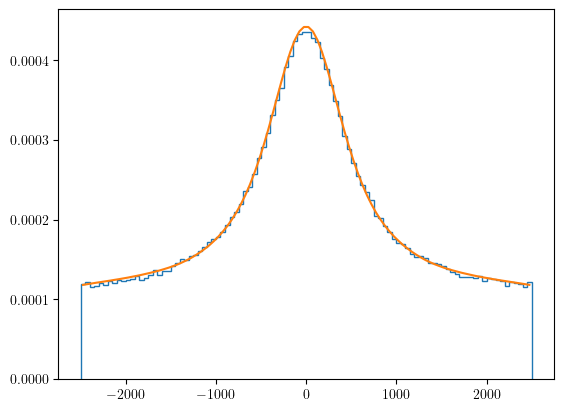

In [135]:
j, k = 0, 0

test = P_vphys_R_hists(vcens, j, k)
test2 = P_vphys_R_test(vcens, r_cens[j], Mvirs[k])

test_hist, _, _ = plt.hist(vphyslos[j+k*len(r_cens)], bins=vedges, density=True, histtype='step', color=f'C{k}')
#plt.scatter(vcens, test, s=3)

plt.plot(vcens, test2, c='C1')

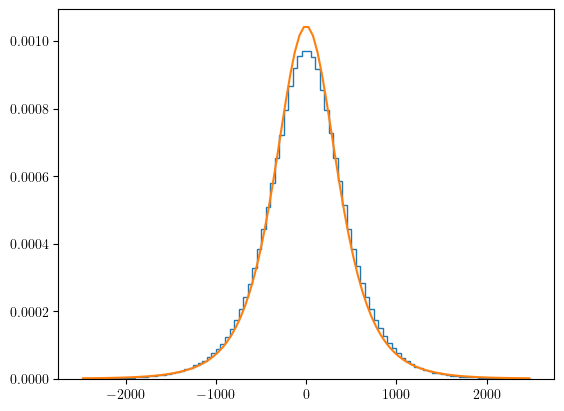

In [139]:
j, k = 9, 0

test2 = P_vpec_R_test(vcens, r_cens[j], Mvirs[k])

test_hist, _, _ = plt.hist(vpeclos[j+k*len(r_cens)], bins=vedges, density=True, histtype='step', color=f'C{k}')

plt.plot(vcens, test2, c='C1')

In [12]:
vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

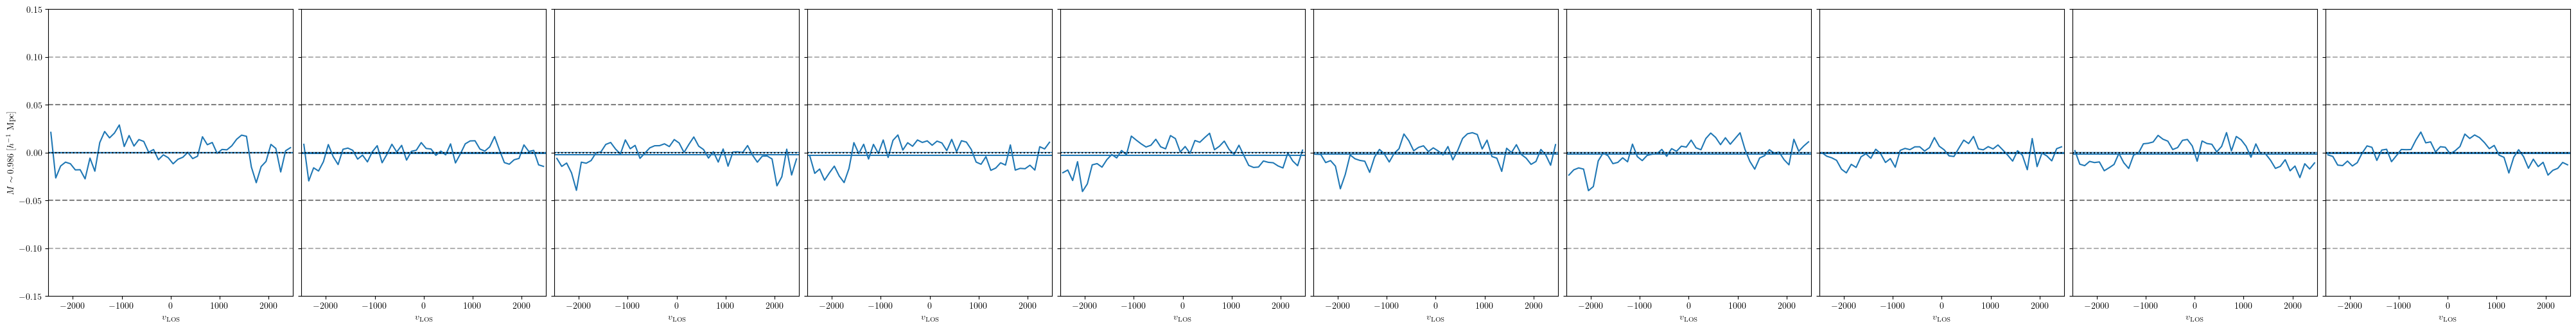

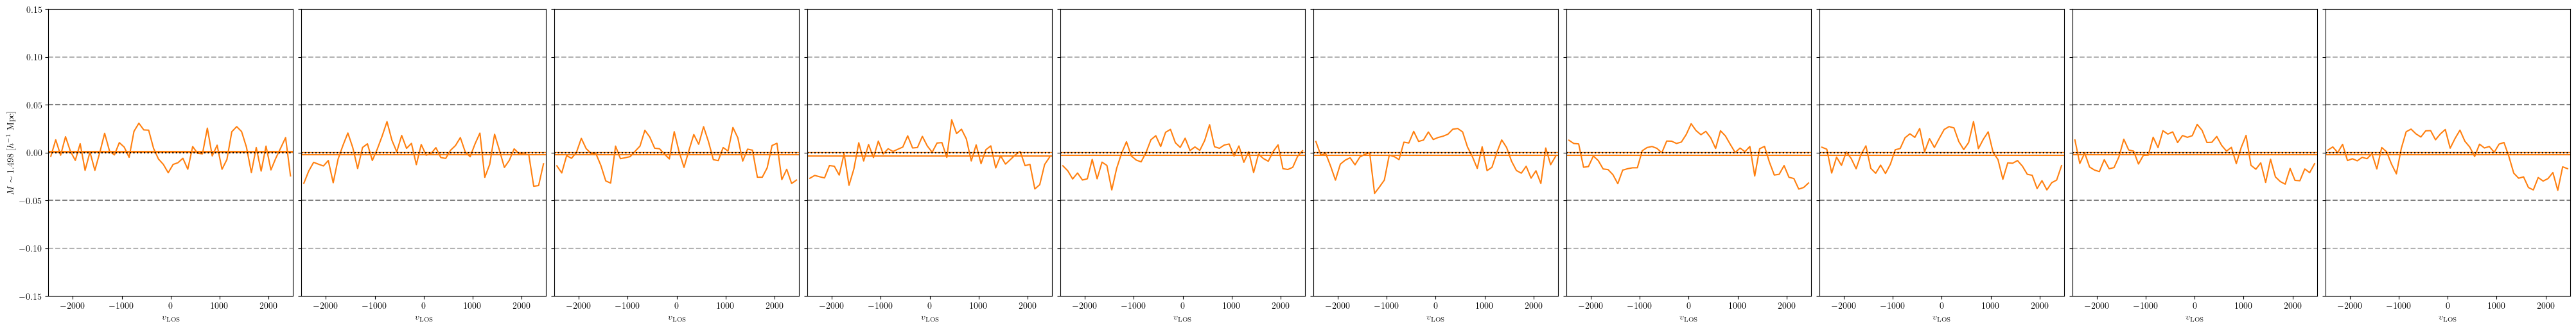

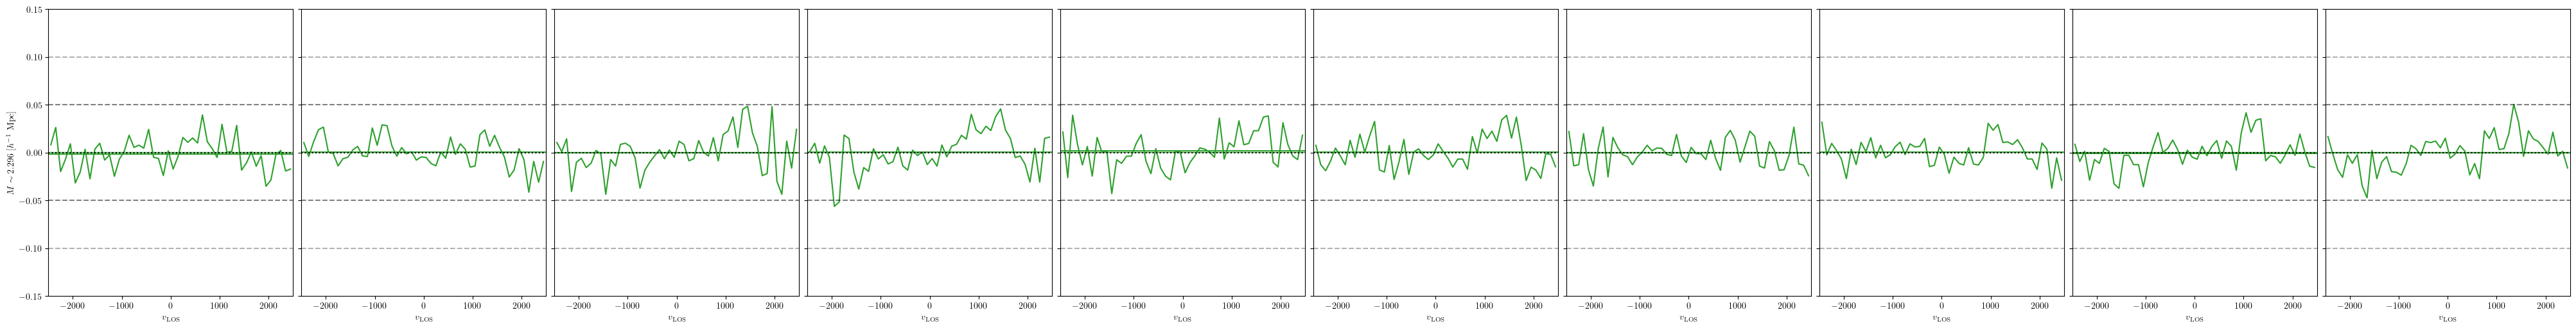

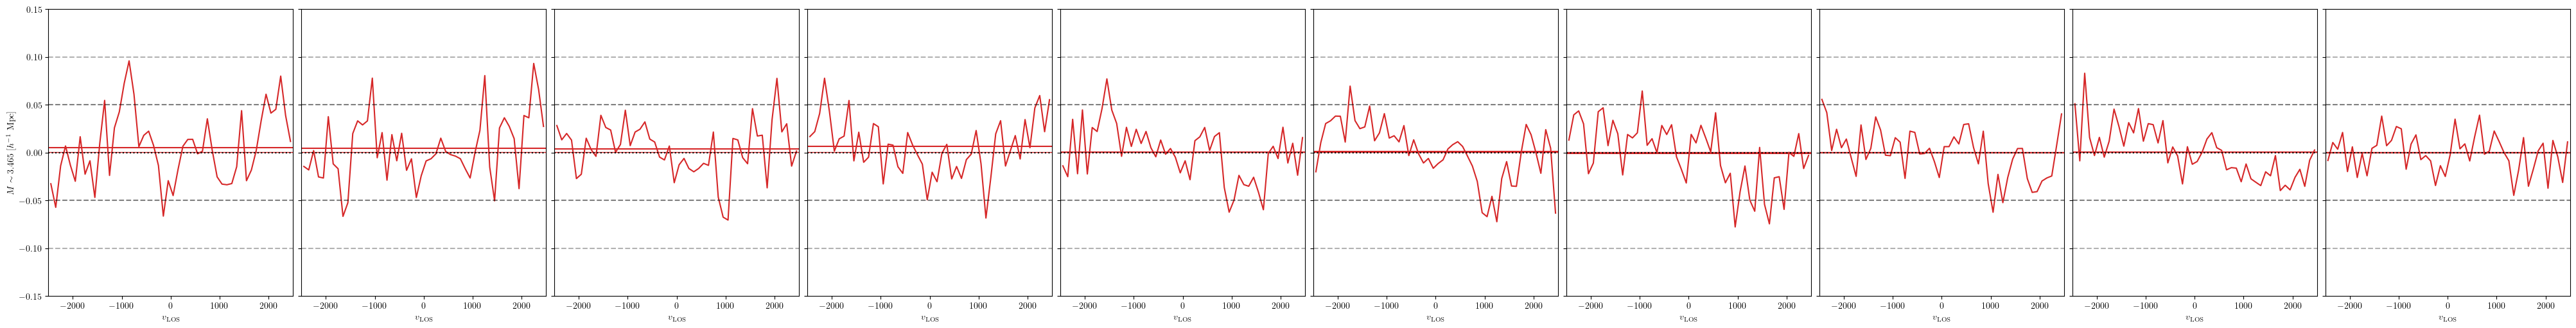

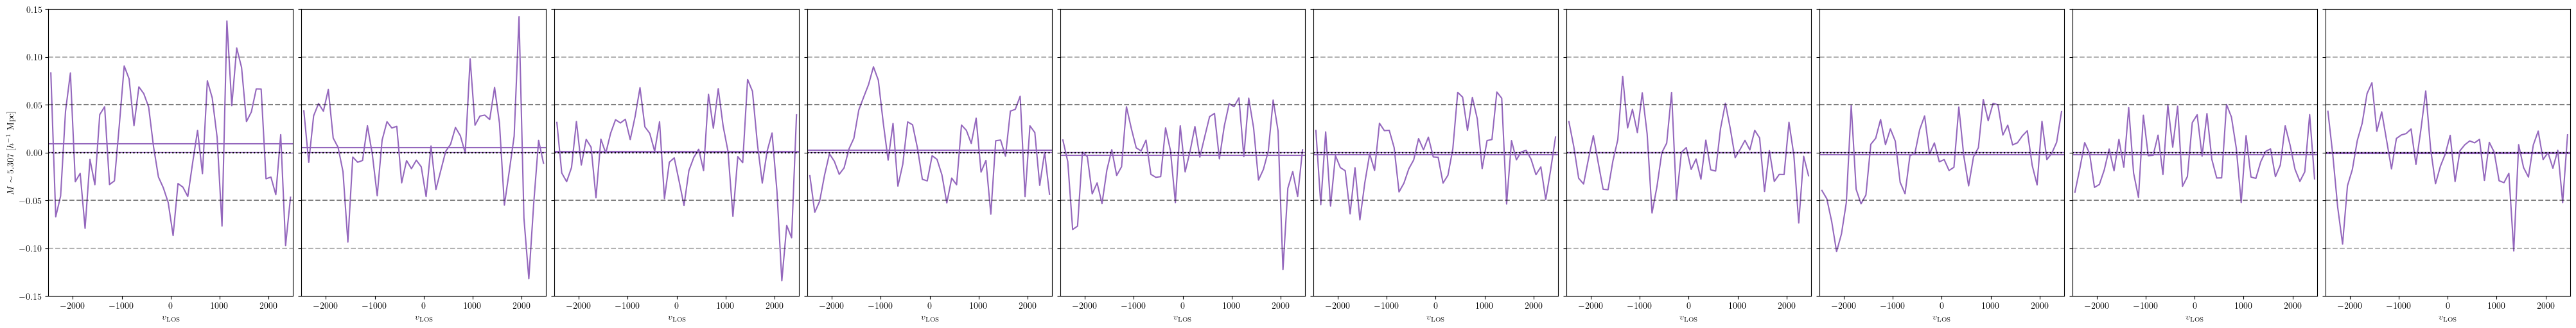

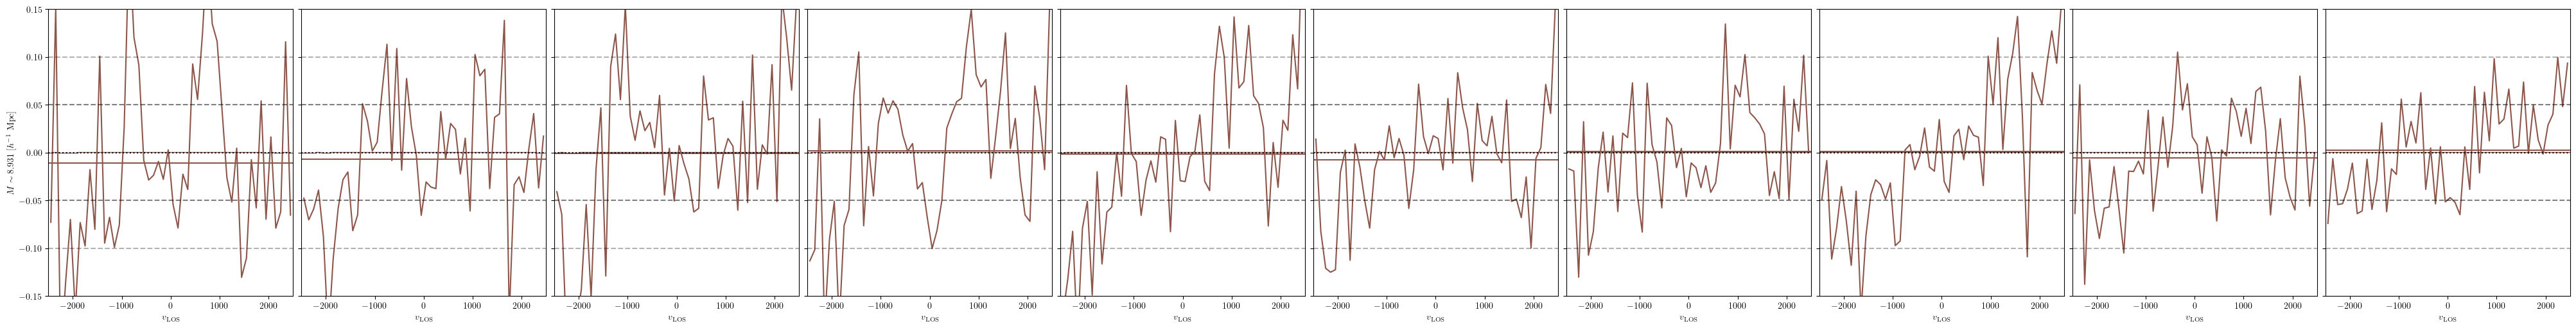

In [13]:
means = np.zeros((len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos[index], bins=vedges, density=True, histtype='step', color=f'C{k}')
        model = P_vphys_R(vcens, r_cens[i], Mvirs[k])

        ax[i].plot(vcens, (hist-model)/model, c=f'C{k}')

        ax[i].axhline(np.mean((hist-model)/model), c=f'C{k}') 

        means[k, i] = np.mean((hist-model)/model)

        ax[i].axhline(0, ls=':', color='k')
        ax[i].axhline(0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(-0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(0.1, ls='--', color='k', alpha=0.3)
        ax[i].axhline(-0.1, ls='--', color='k', alpha=0.3)

        ax[i].set_xlabel(r"$v_{\rm LOS}$")
        #ax[i].set_yticks([])
        ax[i].set_ylim((-0.15, 0.15))
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M\sim {(Mvirs[k]/1e14):.3f} \ [h^{{-1}}$ Mpc]")

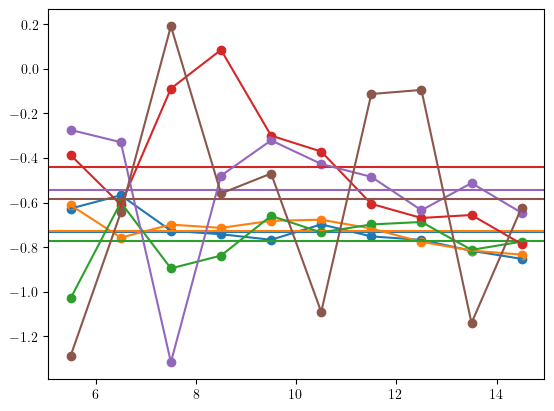

In [116]:
for k in range(len(Mvirs)):
    plt.scatter(r_cens, means[k]*100, label=f'M={Mvirs[k]/1e14:.2f}')
    plt.plot(r_cens, means[k]*100, label=f'M={Mvirs[k]/1e14:.2f}')

    plt.axhline(np.mean(means[k]*100), c=f"C{k}")


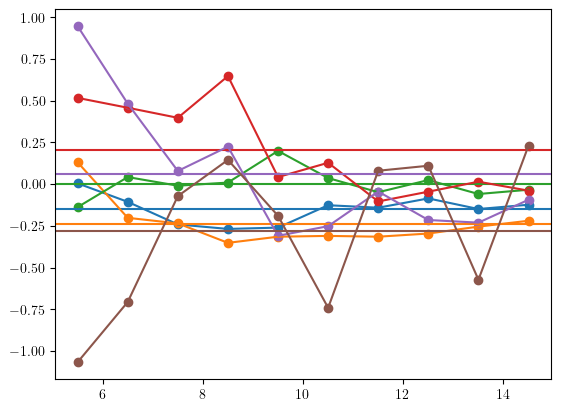

In [14]:
for k in range(len(Mvirs)):
    plt.scatter(r_cens, means[k]*100, label=f'M={Mvirs[k]/1e14:.2f}')
    plt.plot(r_cens, means[k]*100, label=f'M={Mvirs[k]/1e14:.2f}')

    plt.axhline(np.mean(means[k]*100), c=f"C{k}")


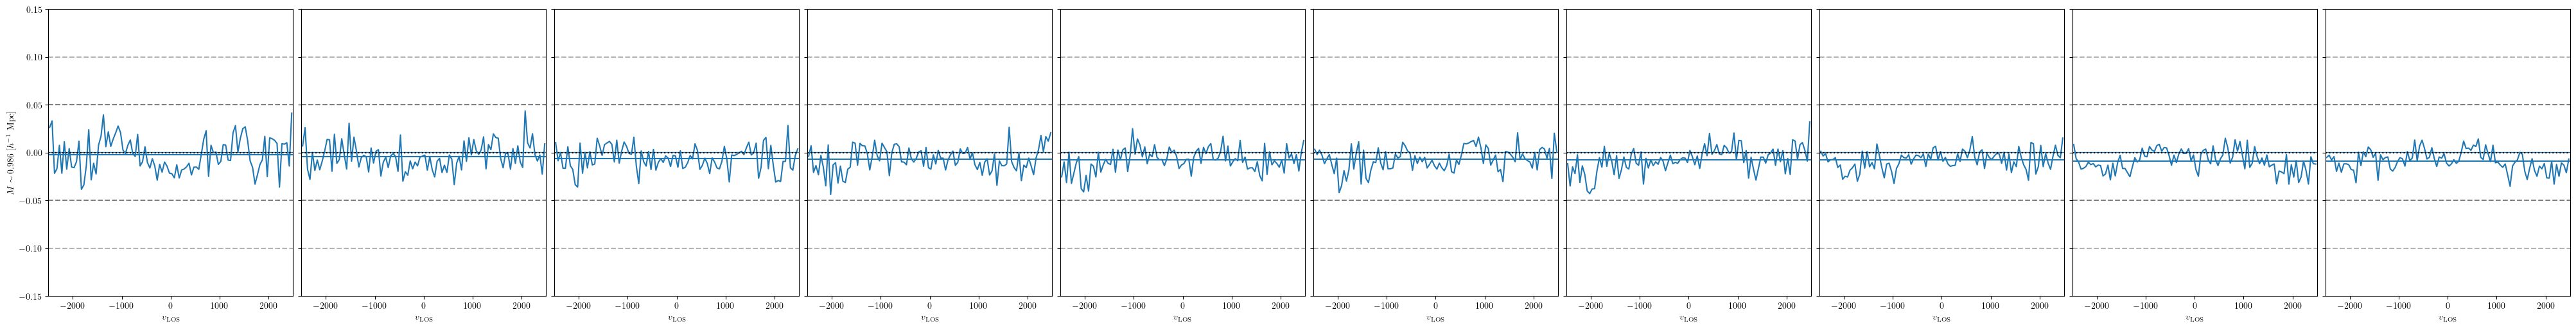

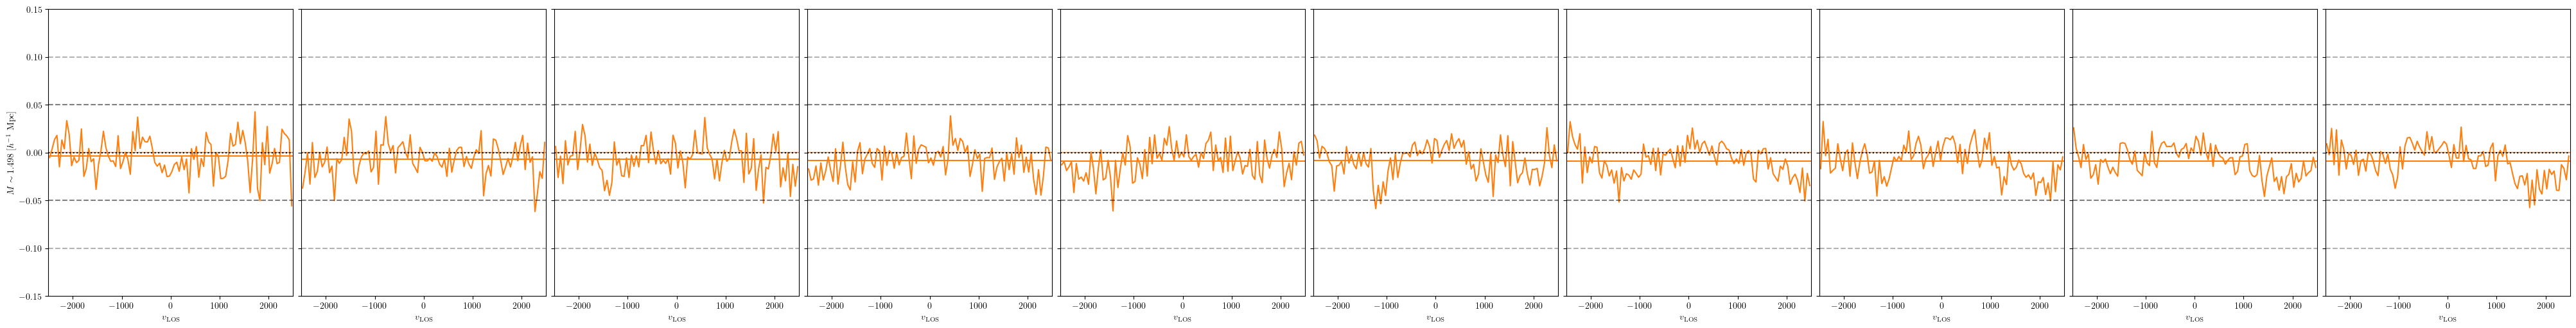

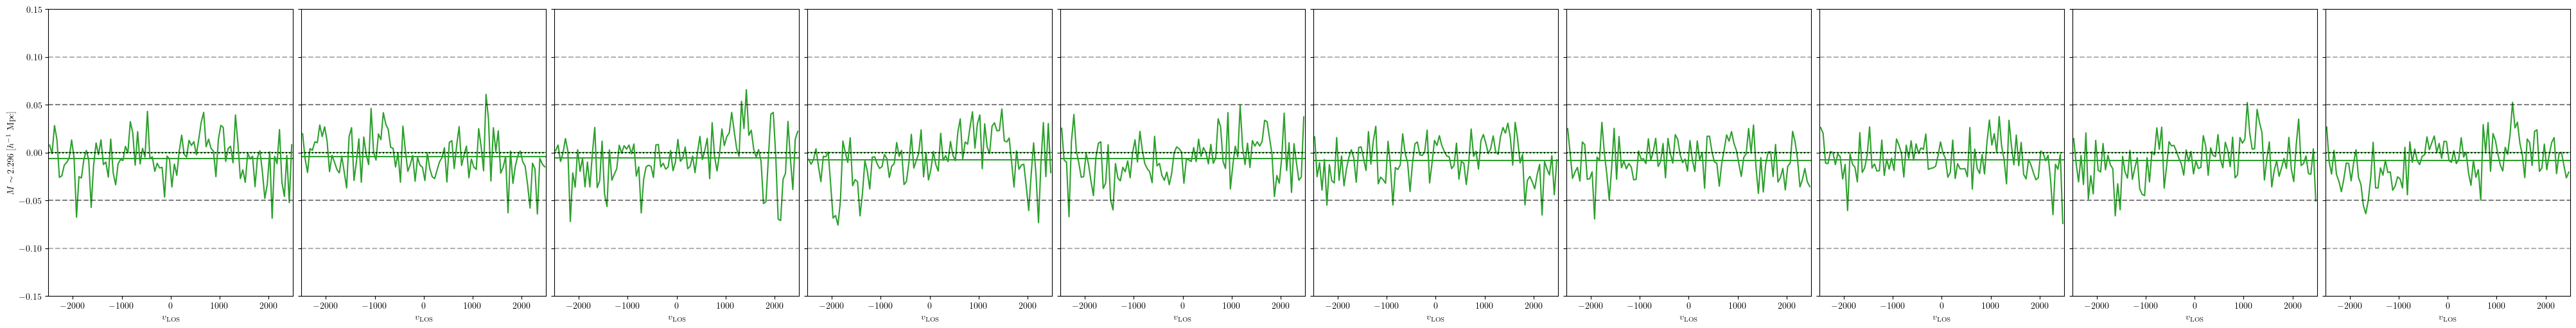

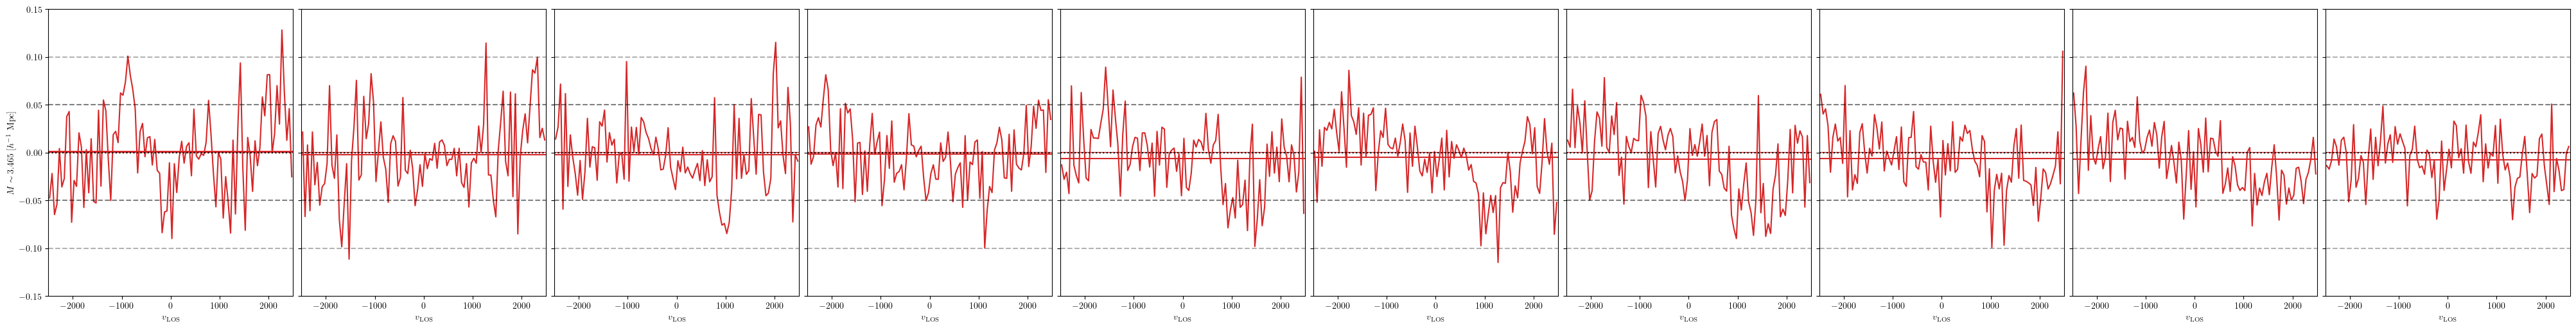

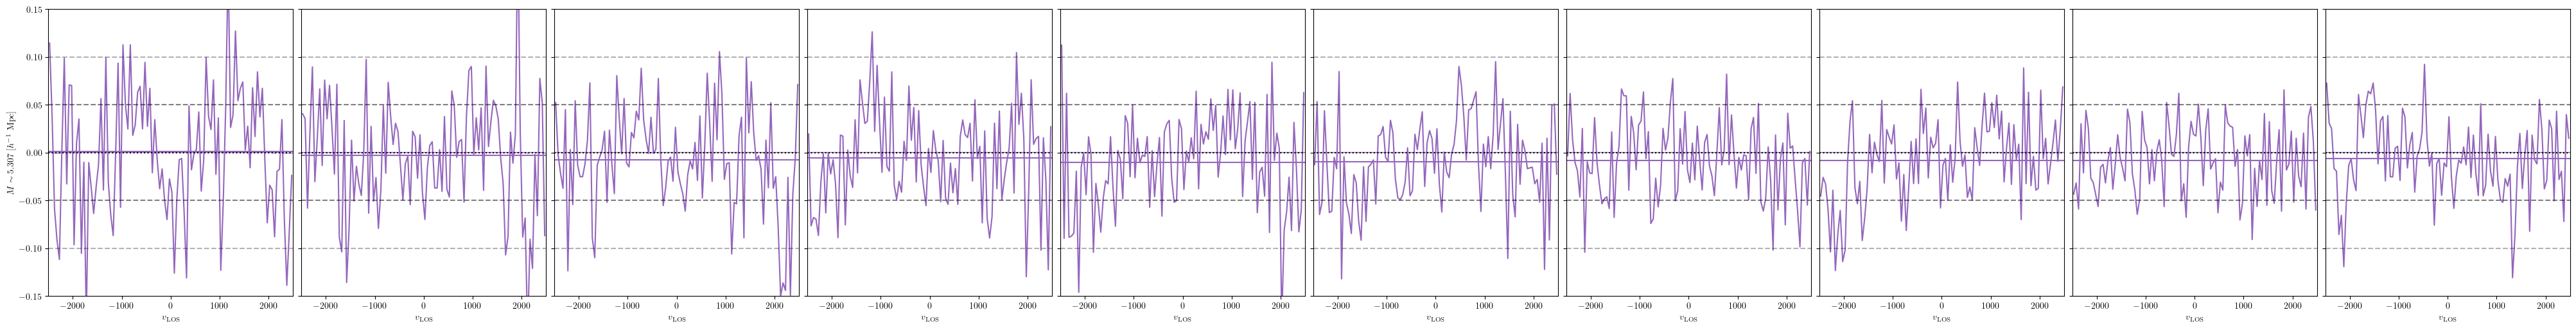

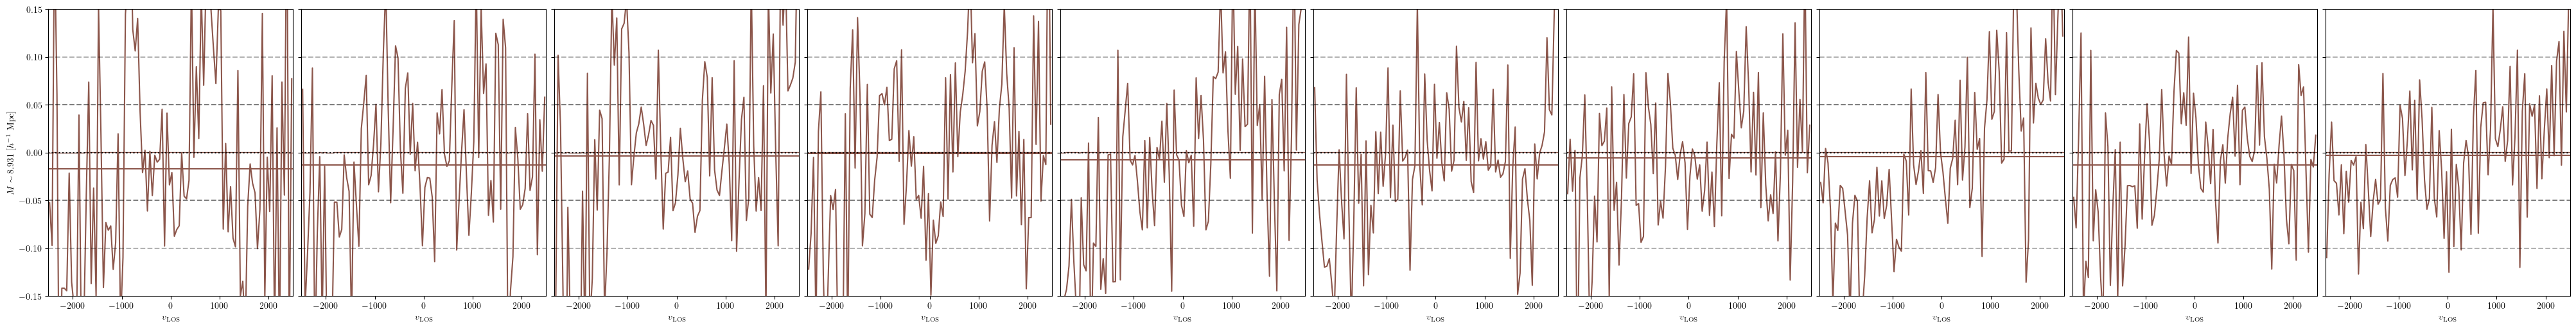

In [126]:
means = np.zeros((len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos[index], bins=vedges, density=True, histtype='step', color=f'C{k}')
        model = P_vphys_R_test(vcens, r_cens[i], Mvirs[k])

        ax[i].plot(vcens, (hist-model)/model, c=f'C{k}')

        ax[i].axhline(np.mean((hist-model)/model), c=f'C{k}') 

        means[k, i] = np.mean((hist-model)/model)

        ax[i].axhline(0, ls=':', color='k')
        ax[i].axhline(0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(-0.05, ls='--', color='k', alpha=0.5)
        ax[i].axhline(0.1, ls='--', color='k', alpha=0.3)
        ax[i].axhline(-0.1, ls='--', color='k', alpha=0.3)

        ax[i].set_xlabel(r"$v_{\rm LOS}$")
        #ax[i].set_yticks([])
        ax[i].set_ylim((-0.15, 0.15))
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M\sim {(Mvirs[k]/1e14):.3f} \ [h^{{-1}}$ Mpc]")

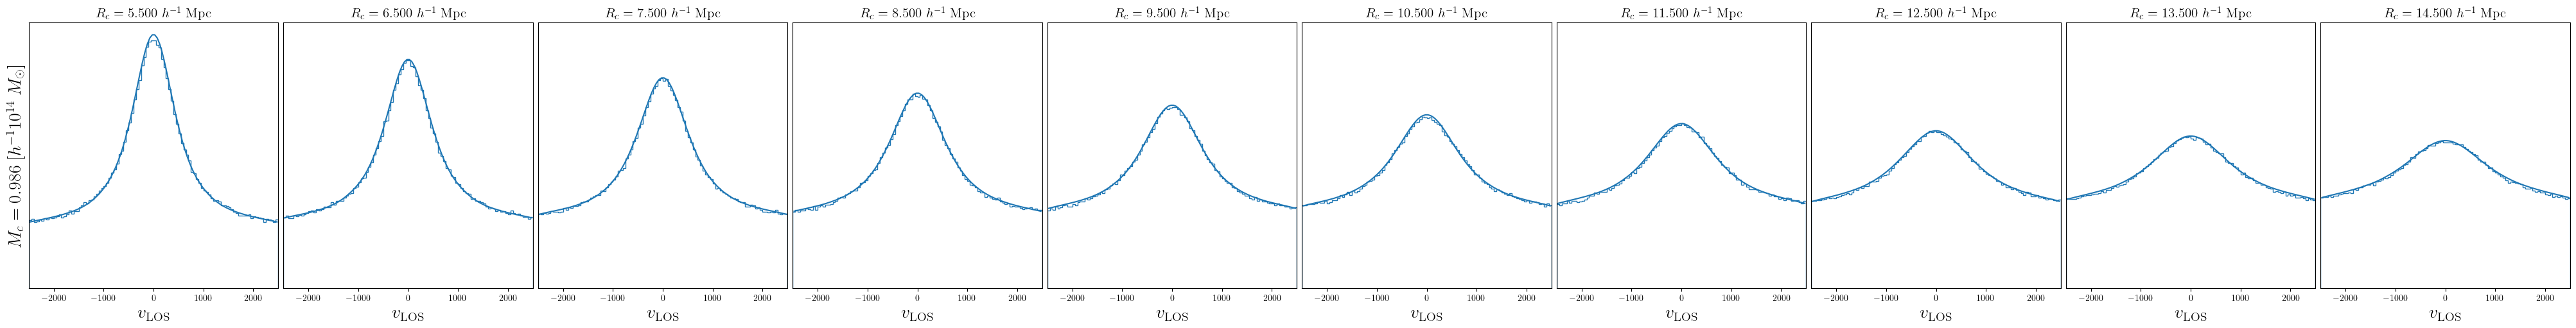

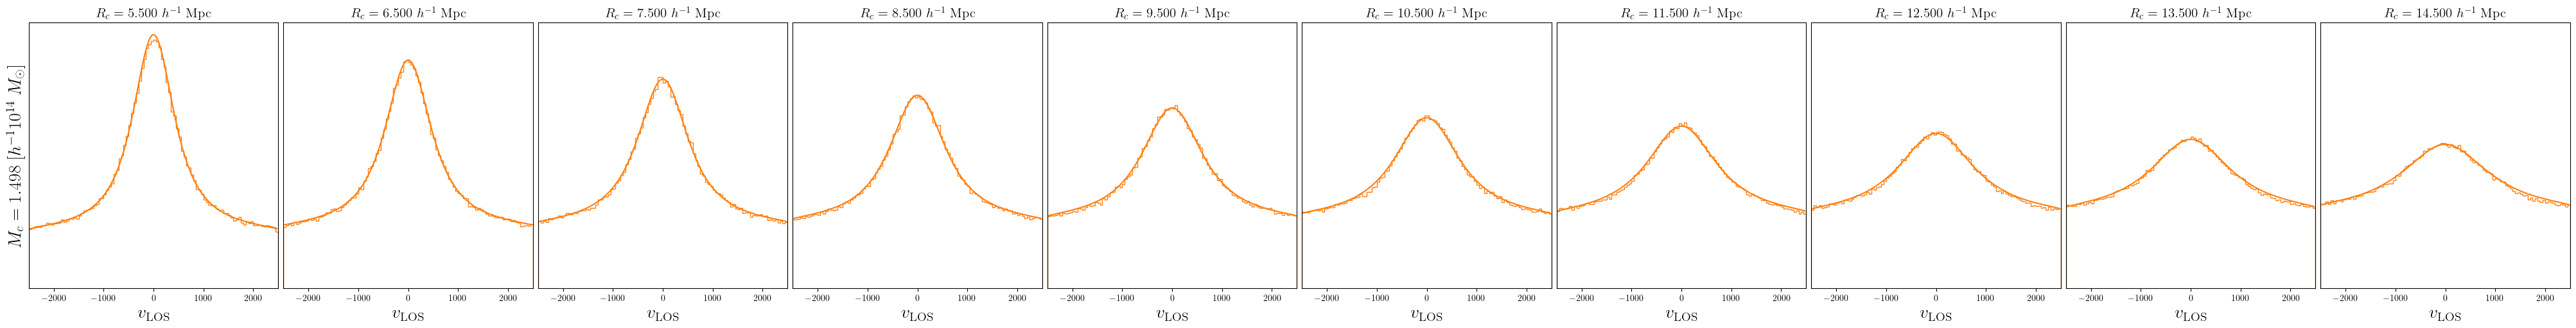

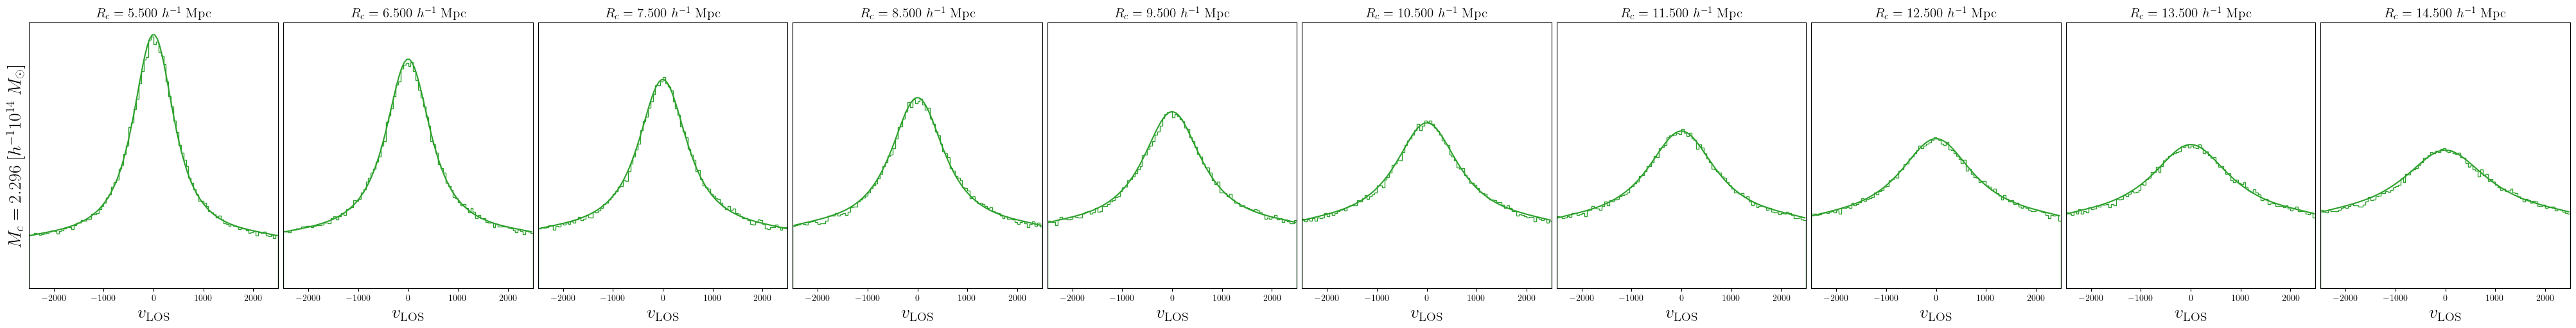

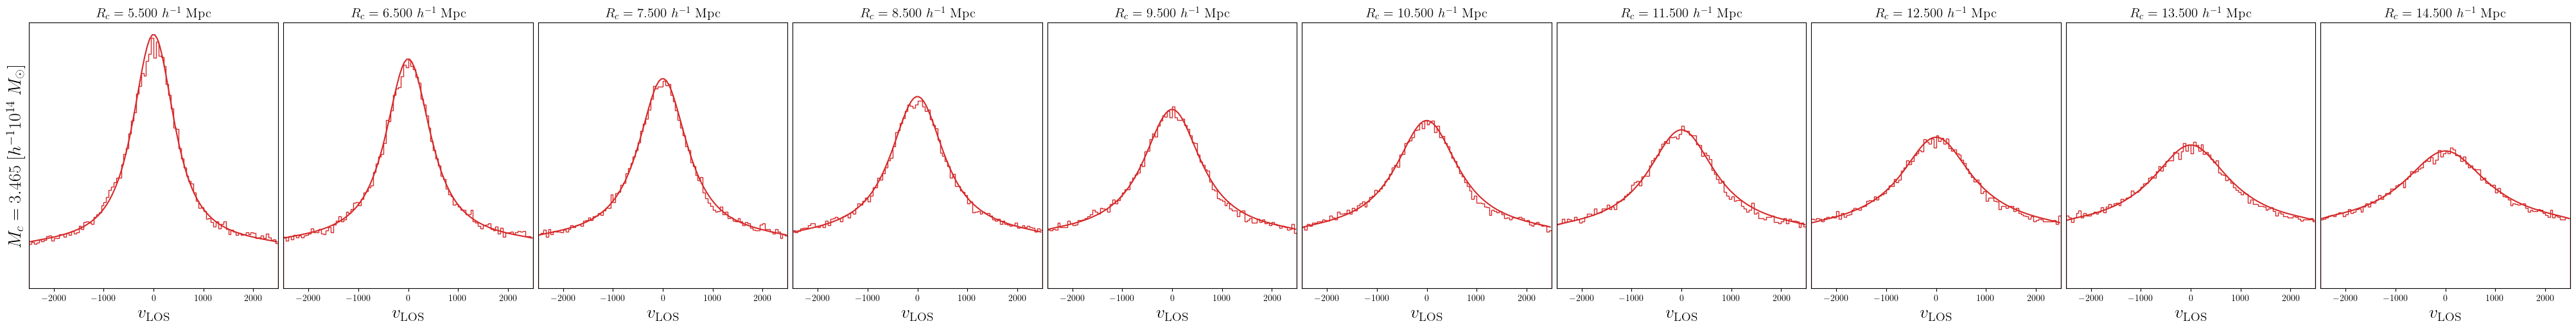

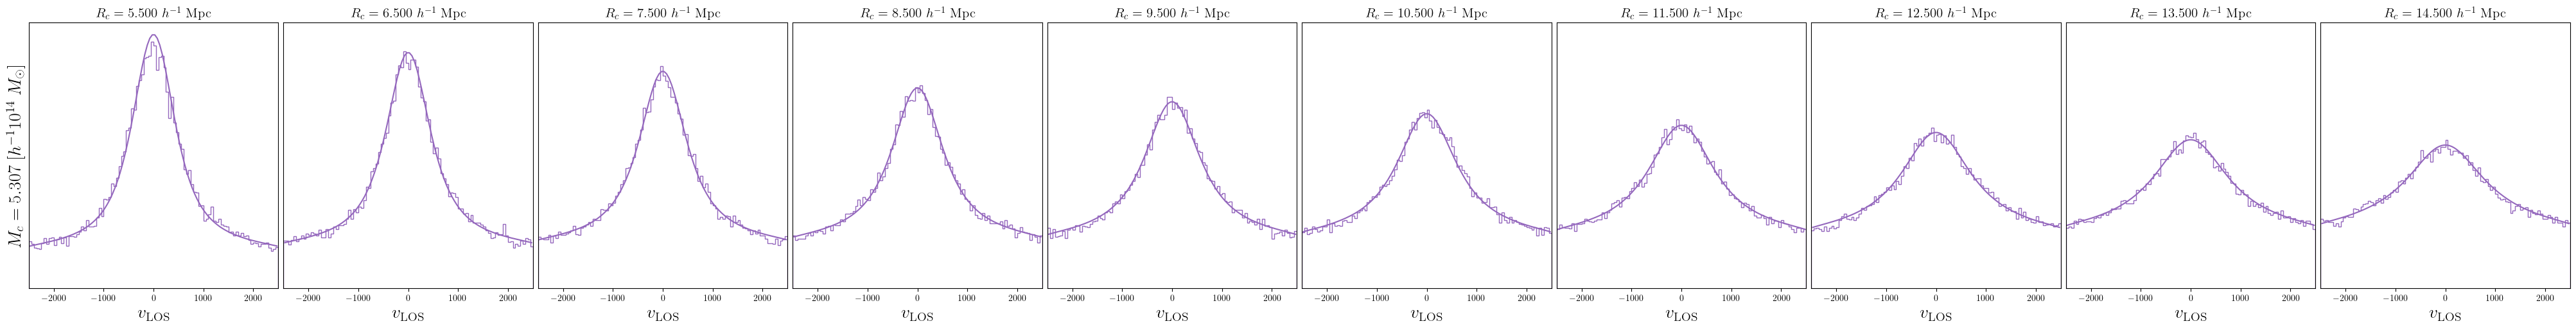

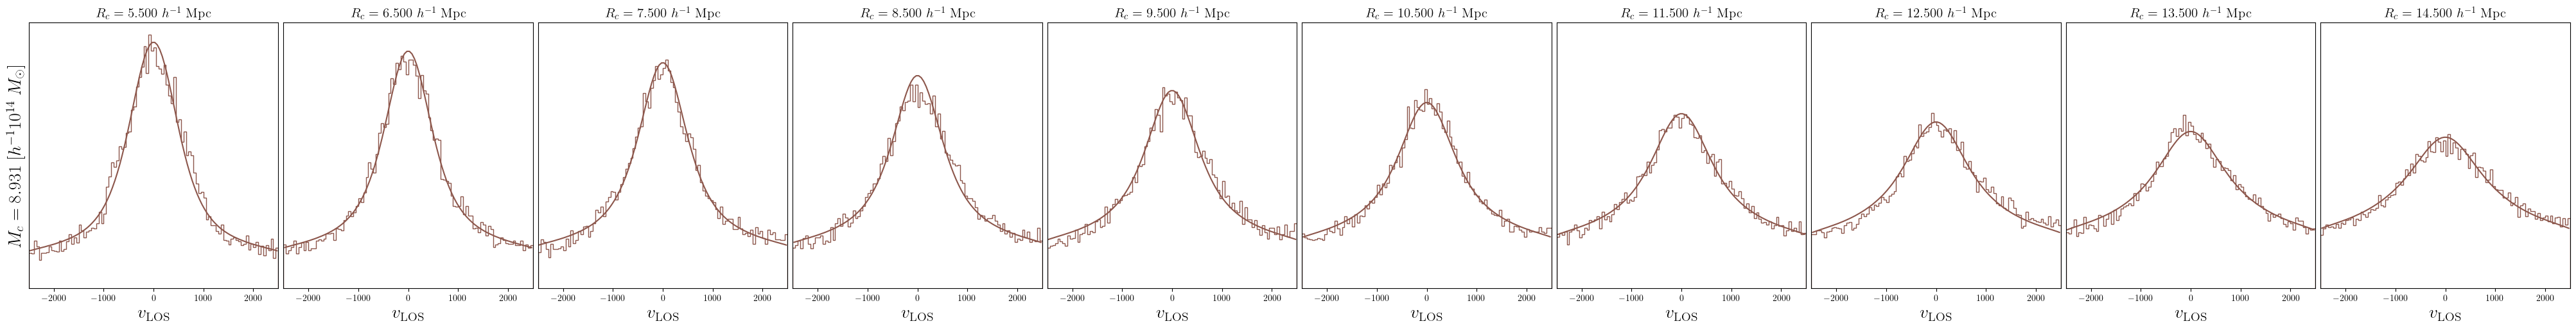

In [128]:

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos[index], bins=vedges, density=True, histtype='step', color=f'C{k}')

        ax[i].plot(vcens, P_vphys_R_test(vcens, r_cens[i], Mvirs[k]), c=f'C{k}')
        
        ax[i].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[i].set_title(rf"$R_c = {r_cens[i]:.3f} \ h^{{-1}}$ Mpc", fontsize=15)
        ax[i].set_yticks([])
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M_c = {(Mvirs[k]/1e14):.3f} \ [h^{{-1}} 10^{{14}} \ M_\odot]$", fontsize=20)

Success!!!!!